# Renderer

## Setup

In [2]:
from PIL import Image, ImageDraw
import sys
import json
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 20)

print("Setup complete!")

# Import actual renderer being used in training
try:
    from src.modifiers.features.renderer import StrokeRenderer, render_stroke_to_image
except ImportError:
    # Fallback if src not in path (should be handled by sys.path.insert)
    sys.path.append(str(Path.cwd().parent))
    from src.modifiers.features.renderer import StrokeRenderer, render_stroke_to_image


Setup complete!


## Load and prepare data

In [3]:
# Define data paths
DATA_DIR = Path.cwd().parent / "data"/ "raw"

# List all contributor folders
contributor_folders = [d for d in DATA_DIR.iterdir() if d.is_dir()]
print(f"Data directory: {DATA_DIR}")
print(f"\nContributors found: {len(contributor_folders)}")
for folder in contributor_folders:
    files = list(folder.glob('*.json'))
    print(f"  - {folder.name}: {len(files)} files")

Data directory: c:\Users\huybh\onedrive\documents\onepen\data\raw

Contributors found: 4
  - Contributor_Esh: 17 files
  - Contributor_Linh: 12 files
  - Contributor_Quang: 14 files
  - Contributor_Sang: 15 files


In [4]:
def load_json_file(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Handle both formats: {"modifiers": [...]} or [...]
    if isinstance(data, dict):
        modifiers = data.get("modifiers", [])
    else:
        modifiers = data

    return modifiers

def load_all_data(data_dir):
    """Load all stroke data with metadata."""
    all_strokes = []
    
    for folder in data_dir.iterdir():
        if not folder.is_dir():
            continue
            
        for json_file in folder.glob('*.json'):
            modifiers = load_json_file(json_file)
            
            for mod in modifiers:
                stroke = mod.get('stroke', [])
                if len(stroke) < 2:
                    continue
                    
                all_strokes.append({
                    'type': mod.get('type', 'unknown'),
                    'stroke': stroke,
                    'contributor': folder.name,
                    'source_file': json_file.stem,
                    'num_points': len(stroke),
                })
    
    return all_strokes

# Load all data
raw_data = load_all_data(DATA_DIR)
print(f"\nTotal strokes loaded: {len(raw_data)}")


Total strokes loaded: 3279


In [5]:
def render_stroke_to_image(
    stroke: list[dict],
    img_size: int = 136,
    line_width: int = 3,
) -> np.ndarray:
    # Handle empty stroke
    if not stroke or len(stroke) < 2:
        return np.ones((img_size, img_size), dtype=np.uint8) * 255

    # Create white image
    img = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(img)

    # Add margin to prevent clipping
    margin = line_width
    draw_size = img_size - 2 * margin

    # Scale normalized coordinates to image space
    xs = np.clip([pt["x"] for pt in stroke], 0, 1)
    ys = np.clip([pt["y"] for pt in stroke], 0, 1)

    scaled_xs = [margin + x * draw_size for x in xs]
    scaled_ys = [margin + y * draw_size for y in ys]

    # Draw stroke
    points = list(zip(scaled_xs, scaled_ys))
    draw.line(points, fill=0, width=line_width)

    return np.array(img)


Renderer Output Shape: (200, 200, 3)


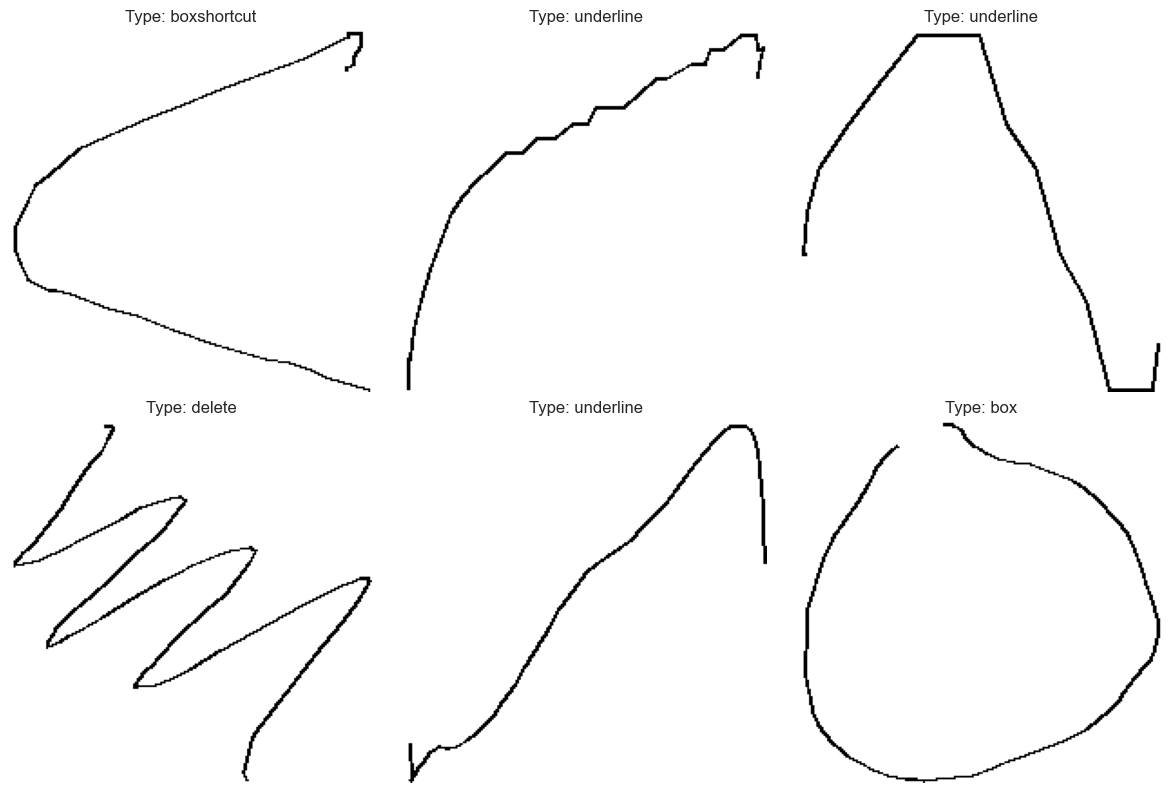

In [6]:
# Visualize samples using the Training Renderer
import random

# Initialize the renderer with same config as training
renderer = StrokeRenderer(
    img_size=200,
    line_width=2,
    to_rgb=True,
    normalize_pixels=True
)

# Select 6 random samples
samples = raw_data[:6] if len(raw_data) < 6 else random.sample(raw_data, 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

print(f"Renderer Output Shape: {renderer.output_shape}")

for i, sample in enumerate(samples):
    stroke = sample['stroke']
    label = sample['type']
    
    # Render using the class
    # Note: data in notebook is raw (dictionaries), process_dataset usually handles raw -> norm
    # But StrokeRenderer expects normalized [0,1] coordinates if calling render directly?
    # Let's check renderer.py: render_stroke_to_image clips to 0,1. 
    # Training pipeline uses StrokePreprocessor to normalize first.
    # We should manually normalize here to match pipeline behavior if raw data isn't norm.
    
    # Quick normalization for visualization logic
    xs = [p['x'] for p in stroke]
    ys = [p['y'] for p in stroke]
    if not xs or not ys: continue
    
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    w = max(max_x - min_x, 1e-6)
    h = max(max_y - min_y, 1e-6)
    
    norm_stroke = []
    for p in stroke:
        norm_stroke.append({
            'x': (p['x'] - min_x) / w,
            'y': (p['y'] - min_y) / h
        })
    
    img = renderer.render(norm_stroke)
    
    # Plot (imshow expects float [0,1] or int [0,255])
    # StrokeRenderer with normalize_pixels=True returns float [0,1]
    axes[i].imshow(img)
    axes[i].set_title(f"Type: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
def render_stroke_smooth(
    stroke: list[dict],
    img_size: int = 136,
    line_width: int = 2,
    normalize: bool = False
) -> np.ndarray:
    """Render stroke with quadratic bezier smoothing (matching draw.js)."""
    if not stroke or len(stroke) < 2:
        return np.ones((img_size, img_size), dtype=np.uint8) * 255
    
    # Create white image
    img = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(img)
    
    margin = line_width
    draw_size = img_size - 2 * margin
    
    # Normalize if requested (or expect already normalized input)
    if normalize:
        xs = [pt["x"] for pt in stroke]
        ys = [pt["y"] for pt in stroke]
        min_x, max_x = min(xs), max(xs)
        min_y, max_y = min(ys), max(ys)
        w = max(max_x - min_x, 1e-6)
        h = max(max_y - min_y, 1e-6)
        pts = []
        for p in stroke:
            pts.append(((p["x"] - min_x) / w, (p["y"] - min_y) / h))
    else:
        # Assume points are dictionaries if not normalized here, but logic below uses tuples mostly
        # Or handle raw dict input
        # Let's standardize to scaled pixel coordinates first
        xs = np.clip([pt["x"] for pt in stroke], 0, 1)
        ys = np.clip([pt["y"] for pt in stroke], 0, 1)
        pts = []
        for x, y in zip(xs, ys):
            pts.append((x, y))
            
    # Scale to canvas
    scaled_pts = [(margin + p[0] * draw_size, margin + p[1] * draw_size) for p in pts]
    
    if len(scaled_pts) < 3:
        draw.line(scaled_pts, fill=0, width=line_width)
        return np.array(img)
        
    # Draw smooth quadratic curves
    # Helper for quadratic bezier points
    def get_quad_points(p0, p1, p2, steps=10):
        points = []
        for t in np.linspace(0, 1, steps):
            x = (1-t)**2 * p0[0] + 2*(1-t)*t * p1[0] + t**2 * p2[0]
            y = (1-t)**2 * p0[1] + 2*(1-t)*t * p1[1] + t**2 * p2[1]
            points.append((x, y))
        return points
    
    # Logic from draw.js: drawStroke function
    # ctx.moveTo(stroke[0])
    # loop 1 to len-2:
    #   quadraticCurveTo(curr.x, curr.y, mid.x, mid.y)
    
    full_path = [scaled_pts[0]]
    
    for i in range(1, len(scaled_pts) - 1):
        # The control point is the current point in iteration
        control = scaled_pts[i]
        next_pt = scaled_pts[i+1]
        
        # The end point of the curve is the midpoint between current and next
        end_x = (control[0] + next_pt[0]) / 2
        end_y = (control[1] + next_pt[1]) / 2
        end = (end_x, end_y)
        
        # The start point of the curve is the end of the previous curve
        # Except for the very first curve (i==1), which starts at p0
        if i == 1:
            start = scaled_pts[0]
        else:
            # Re-calculate previous midpoint to be safe/explicit
            prev_control = scaled_pts[i-1]
            start_x = (prev_control[0] + control[0]) / 2
            start_y = (prev_control[1] + control[1]) / 2
            start = (start_x, start_y)
            
        curve = get_quad_points(start, control, end)
        full_path.extend(curve)
        
    # Last straight line to the very last point
    full_path.append(scaled_pts[-1])
    
    # Draw all as a single line
    draw.line(full_path, fill=0, width=line_width)
    
    return np.array(img)


Left: Standard Training Renderer (Linear)
Right: Smoothed Renderer (Quadratic Bezier - JS Logic)


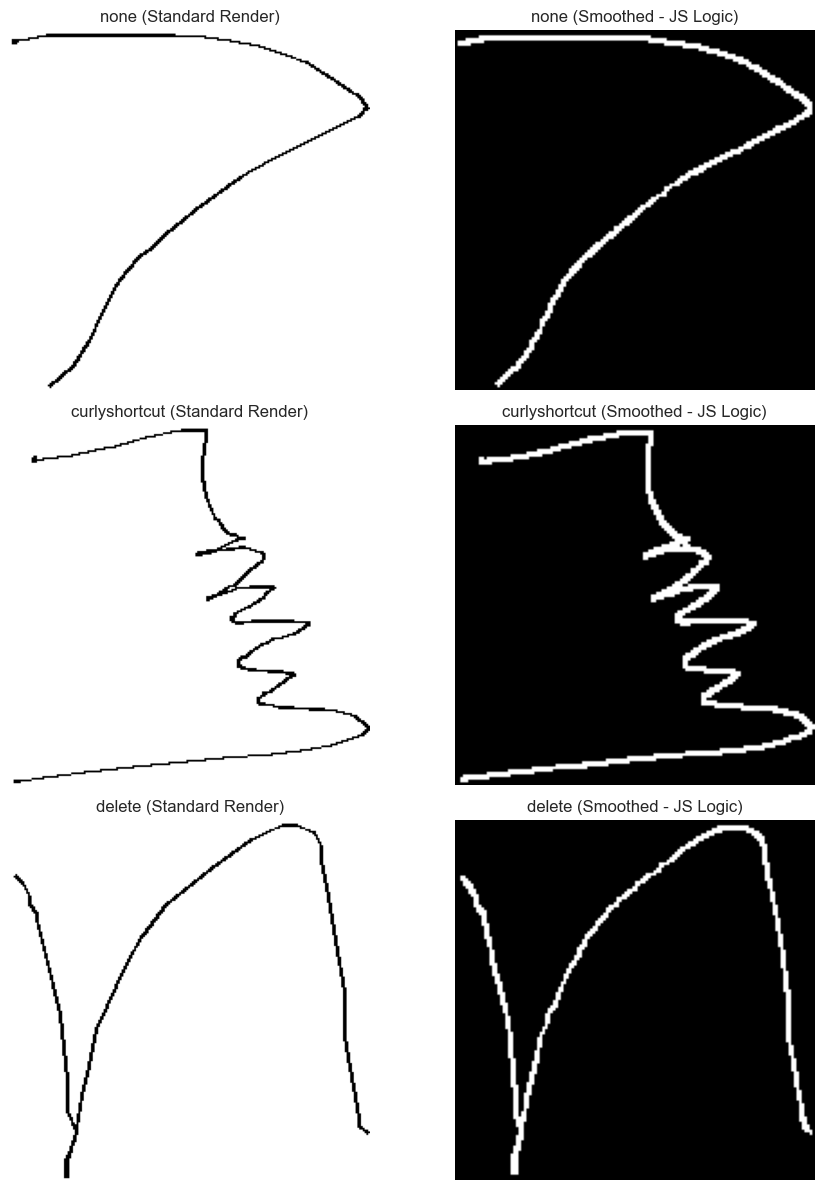

In [8]:
# Visualize Comparison: Standard vs Smoothed (JS-like)
import random

samples = raw_data[:3] if len(raw_data) < 3 else random.sample(raw_data, 3)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
plt.subplots_adjust(hspace=0.3)

print("Left: Standard Training Renderer (Linear)")
print("Right: Smoothed Renderer (Quadratic Bezier - JS Logic)")

for i, sample in enumerate(samples):
    stroke = sample['stroke']
    label = sample['type']
    
    # 1. Standard Render (Linear)
    # Manually normalize for class-based renderer
    xs = [p['x'] for p in stroke]
    ys = [p['y'] for p in stroke]
    w = max(max(xs) - min(xs), 1e-6)
    h = max(max(ys) - min(ys), 1e-6)
    norm_stroke_std = [{'x': (p['x']-min(xs))/w, 'y': (p['y']-min(ys))/h} for p in stroke]
    
    img_std = renderer.render(norm_stroke_std)
    
    # 2. Smooth Render
    # Pass raw normalized stroke to helper
    img_smooth = render_stroke_smooth(norm_stroke_std, normalize=False)
    
    # Plot Standard
    axes[i, 0].imshow(img_std)
    axes[i, 0].set_title(f"{label} (Standard Render)")
    axes[i, 0].axis('off')
    
    # Plot Smooth
    axes[i, 1].imshow(img_smooth)
    axes[i, 1].set_title(f"{label} (Smoothed - JS Logic)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
def render_stroke_antialiased(
    stroke: list[dict],
    img_size: int = 96,
    line_width: int = 2,
    scale_factor: int = 4,
    normalize: bool = False
) -> np.ndarray:
    """Render with supersampling for anti-aliasing."""
    if not stroke or len(stroke) < 2:
        return np.ones((img_size, img_size), dtype=np.uint8) * 255
    
    # Render at higher resolution
    large_size = img_size * scale_factor
    large_width = line_width * scale_factor
    
    # Create high-res image
    img = Image.new("L", (large_size, large_size), color=255)
    draw = ImageDraw.Draw(img)
    
    margin = large_width
    draw_size = large_size - 2 * margin
    
    # Process points (similar to standard render but scaled)
    if normalize:
        xs = [pt["x"] for pt in stroke]
        ys = [pt["y"] for pt in stroke]
        min_x, max_x = min(xs), max(xs)
        min_y, max_y = min(ys), max(ys)
        w = max(max_x - min_x, 1e-6)
        h = max(max_y - min_y, 1e-6)
        pts = []
        for p in stroke:
            pts.append(((p["x"] - min_x) / w, (p["y"] - min_y) / h))
    else:
        xs = np.clip([pt["x"] for pt in stroke], 0, 1)
        ys = np.clip([pt["y"] for pt in stroke], 0, 1)
        pts = list(zip(xs, ys))
            
    # Scale points to large canvas
    scaled_pts = [(margin + p[0] * draw_size, margin + p[1] * draw_size) for p in pts]
    
    # Draw jagged line on large canvas
    draw.line(scaled_pts, fill=0, width=large_width)
    
    # Resize down with high-quality resampling (LANCZOS)
    img = img.resize((img_size, img_size), resample=Image.Resampling.LANCZOS)
    
    return np.array(img)


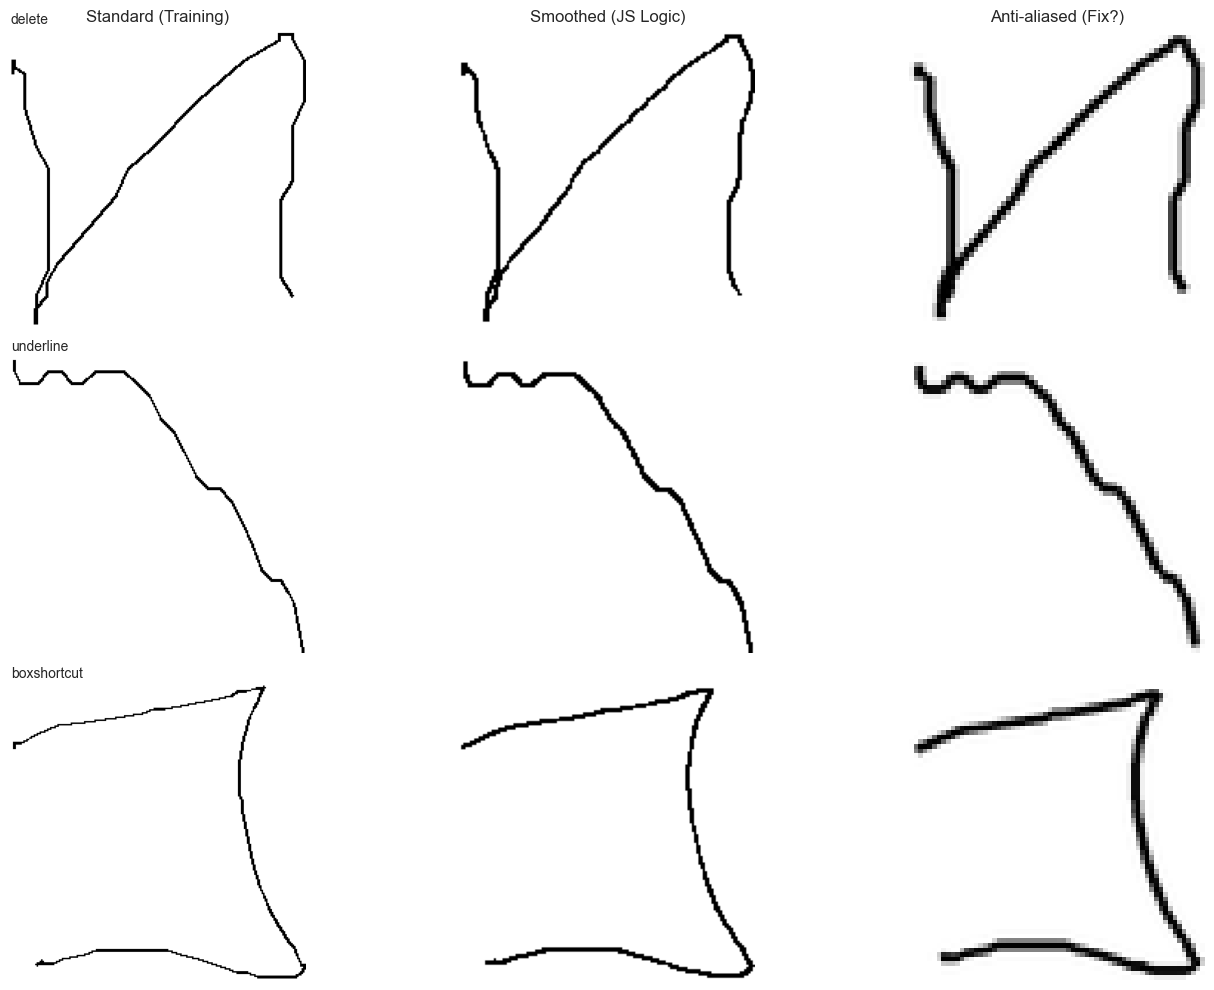

In [12]:
# Visualize Comparison: Standard vs Smoothed (JS) vs Anti-aliased (HQ)
import random

samples = raw_data[:2] if len(raw_data) < 2 else random.sample(raw_data, 3)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.2)

cols = ["Standard (Training)", "Smoothed (JS Logic)", "Anti-aliased (Fix?)"]
for ax, col in zip(axes[0], cols):
    ax.set_title(col)

for i, sample in enumerate(samples):
    stroke = sample['stroke']
    label = sample['type']
    
    # Pre-calc normalized for standard render
    xs = [p['x'] for p in stroke]
    ys = [p['y'] for p in stroke]
    w = max(max(xs) - min(xs), 1e-6)
    h = max(max(ys) - min(ys), 1e-6)
    norm_stroke_std = [{'x': (p['x']-min(xs))/w, 'y': (p['y']-min(ys))/h} for p in stroke]
    
    # 1. Standard
    img_std = renderer.render(norm_stroke_std)
    
    # 2. Smooth
    img_smooth = render_stroke_smooth(norm_stroke_std, normalize=False)
    
    # 3. Anti-aliased
    img_aa = render_stroke_antialiased(norm_stroke_std, normalize=False)
    
    # Display
    # Standard
    axes[i, 0].imshow(img_std)
    axes[i, 0].axis('off')
    axes[i, 0].text(0, -5, f"{label}", ha='left')
    
    # Smooth
    axes[i, 1].imshow(img_smooth, cmap='gray', vmin=0, vmax=255)
    axes[i, 1].axis('off')
    
    # Anti-aliased
    axes[i, 2].imshow(img_aa, cmap='gray', vmin=0, vmax=255)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

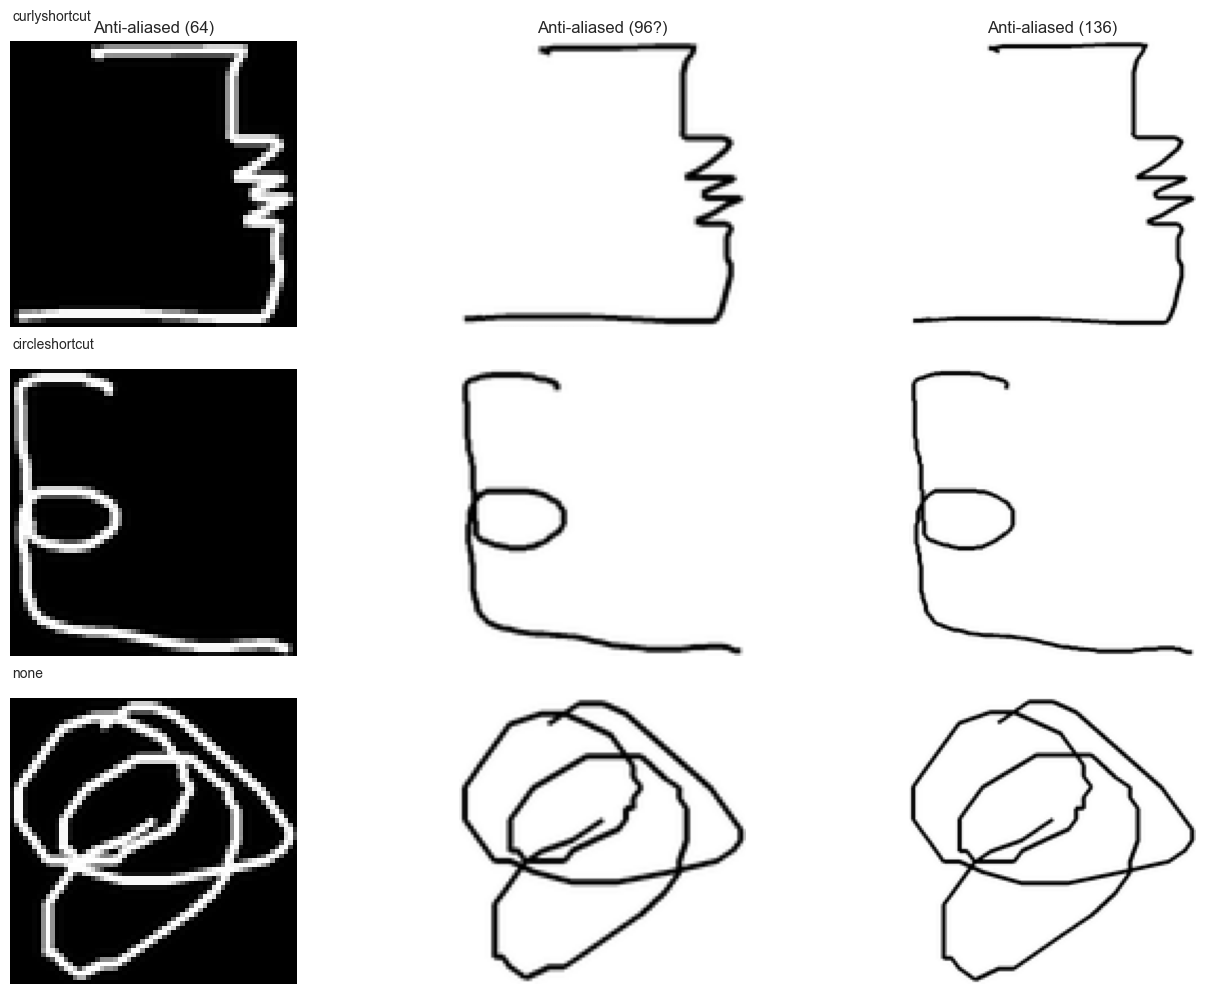

In [15]:
# Visualize Comparison: Standard vs Smoothed (JS) vs Anti-aliased (HQ)
import random

samples = raw_data[:2] if len(raw_data) < 2 else random.sample(raw_data, 3)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.2)

cols = ["Anti-aliased (64)", "Anti-aliased (96?)", "Anti-aliased (136)"]
for ax, col in zip(axes[0], cols):
    ax.set_title(col)

for i, sample in enumerate(samples):
    stroke = sample['stroke']
    label = sample['type']
    
    # Pre-calc normalized for standard render
    xs = [p['x'] for p in stroke]
    ys = [p['y'] for p in stroke]
    w = max(max(xs) - min(xs), 1e-6)
    h = max(max(ys) - min(ys), 1e-6)
    norm_stroke_std = [{'x': (p['x']-min(xs))/w, 'y': (p['y']-min(ys))/h} for p in stroke]
    
    # 1. Standard
    img_std = render_stroke_antialiased(norm_stroke_std, normalize=False, img_size=64)
    
    # 2. Smooth
    img_smooth = render_stroke_antialiased(norm_stroke_std, normalize=False, img_size = 98)
    
    # 3. Anti-aliased
    img_aa = render_stroke_antialiased(norm_stroke_std, normalize=False, img_size = 136)
    
    # Display
    # Standard
    axes[i, 0].imshow(img_std)
    axes[i, 0].axis('off')
    axes[i, 0].text(0, -5, f"{label}", ha='left')
    
    # Smooth
    axes[i, 1].imshow(img_smooth, cmap='gray', vmin=0, vmax=255)
    axes[i, 1].axis('off')
    
    # Anti-aliased
    axes[i, 2].imshow(img_aa, cmap='gray', vmin=0, vmax=255)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# Smoothing + Anti-aliasing Investigation
Implementing a renderer that combines Quadratic Bezier smoothing with Supersampling Anti-aliasing.

In [ ]:

def render_stroke_smooth_aa(
    stroke: list[dict],
    img_size: int = 136,
    line_width: int = 2,
    normalize: bool = True,
    scale_factor: int = 4
) -> np.ndarray:
    """Render stroke with quadratic bezier smoothing AND supersampling anti-aliasing."""
    if not stroke or len(stroke) < 2:
        return np.ones((img_size, img_size), dtype=np.uint8) * 255

    # Supersampling dimensions
    target_size = img_size
    super_size = img_size * scale_factor
    super_width = line_width * scale_factor
    
    # Create large white image
    img = Image.new("L", (super_size, super_size), color=255)
    draw = ImageDraw.Draw(img)
    
    # Determine margin (scaled)
    # Using slightly larger margin to ensure thick lines don't get clipped at edges if curves go out
    margin = super_width
    draw_size = super_size - 2 * margin
    
    # Normalize input points if needed, or assume raw dictionaries
    if normalize:
        xs = [pt["x"] for pt in stroke]
        ys = [pt["y"] for pt in stroke]
        if not xs: return np.ones((img_size, img_size), dtype=np.uint8) * 255
        min_x, max_x = min(xs), max(xs)
        min_y, max_y = min(ys), max(ys)
        w = max(max_x - min_x, 1e-6)
        h = max(max_y - min_y, 1e-6)
        pts = []
        for p in stroke:
            pts.append(((p["x"] - min_x) / w, (p["y"] - min_y) / h))
    else:
        # Clip to [0,1] assuming input is already somewhat normalized or raw needing clip
        # Based on previous cells, input seems to be dictionaries with 'x','y'
        # The previous 'render_stroke_smooth' handled raw inputs by clipping.
        xs = np.clip([pt["x"] for pt in stroke], 0, 1)
        ys = np.clip([pt["y"] for pt in stroke], 0, 1)
        pts = list(zip(xs, ys))
            
    # Scale points to the supersampled canvas
    scaled_pts = [(margin + p[0] * draw_size, margin + p[1] * draw_size) for p in pts]
    
    # helper to get quadratic bezier points
    def get_quad_points(p0, p1, p2, steps=20):
        points = []
        # Increase steps based on scale factor to ensure smoothness at high res
        for t in np.linspace(0, 1, steps):
            x = (1-t)**2 * p0[0] + 2*(1-t)*t * p1[0] + t**2 * p2[0]
            y = (1-t)**2 * p0[1] + 2*(1-t)*t * p1[1] + t**2 * p2[1]
            points.append((x, y))
        return points

    if len(scaled_pts) < 3:
        # Not enough points for curves, just draw lines
        draw.line(scaled_pts, fill=0, width=super_width)
    else:
        # Build the full smoothed path
        full_path = [scaled_pts[0]]
        
        for i in range(1, len(scaled_pts) - 1):
            control = scaled_pts[i]
            next_pt = scaled_pts[i+1]
            
            # Midpoint is the end of the current quadratic curve
            end_x = (control[0] + next_pt[0]) / 2
            end_y = (control[1] + next_pt[1]) / 2
            end = (end_x, end_y)
            
            # Start of curve
            if i == 1:
                start = scaled_pts[0]
            else:
                prev_control = scaled_pts[i-1]
                start_x = (prev_control[0] + control[0]) / 2
                start_y = (prev_control[1] + control[1]) / 2
                start = (start_x, start_y)
                
            # Generate curve points
            # Scale steps by scale_factor for high resolution smoothness
            steps = max(10, int(10 * scale_factor)) 
            curve = get_quad_points(start, control, end, steps=steps)
            full_path.extend(curve)
            
        # Connect to the last point
        full_path.append(scaled_pts[-1])
        
        # Draw the smooth path
        draw.line(full_path, fill=0, width=super_width)
    
    # Downscale using LANCZOS for anti-aliasing
    if scale_factor > 1:
        import PIL
        resample_method = getattr(PIL.Image.Resampling, "LANCZOS", getattr(PIL.Image, "LANCZOS", PIL.Image.BICUBIC))
        img = img.resize((target_size, target_size), resample=resample_method)
        
    return np.array(img)


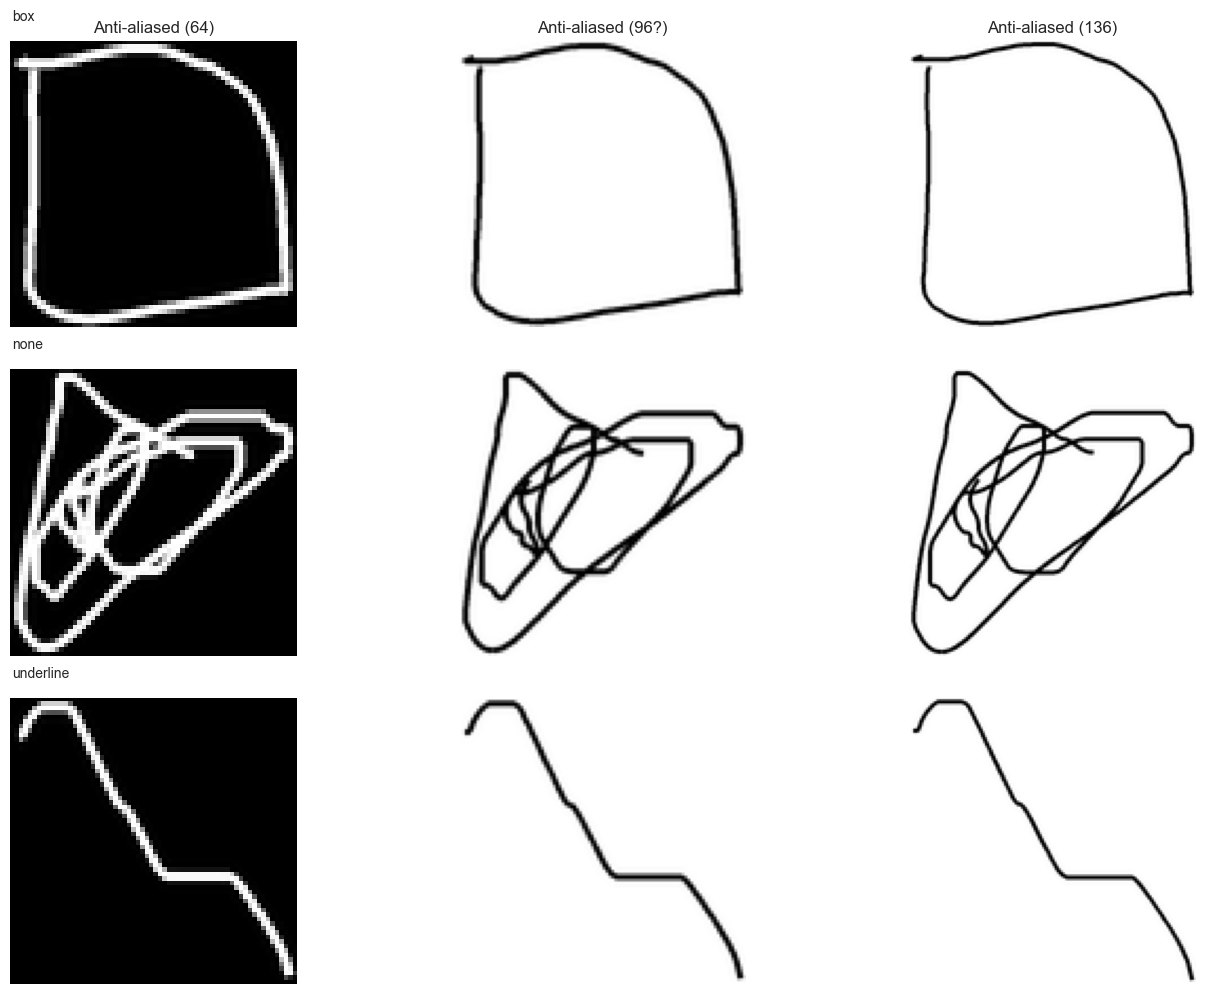

In [19]:
# Visualize Comparison: Standard vs Smoothed (JS) vs Anti-aliased (HQ)
import random

samples = raw_data[:2] if len(raw_data) < 2 else random.sample(raw_data, 3)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.2)

cols = ["Anti-aliased (64)", "Anti-aliased (96?)", "Anti-aliased (136)"]
for ax, col in zip(axes[0], cols):
    ax.set_title(col)

for i, sample in enumerate(samples):
    stroke = sample['stroke']
    label = sample['type']
    
    # Pre-calc normalized for standard render
    xs = [p['x'] for p in stroke]
    ys = [p['y'] for p in stroke]
    w = max(max(xs) - min(xs), 1e-6)
    h = max(max(ys) - min(ys), 1e-6)
    norm_stroke_std = [{'x': (p['x']-min(xs))/w, 'y': (p['y']-min(ys))/h} for p in stroke]
    
    # 1. Standard
    img_std = render_stroke_smooth_aa(norm_stroke_std, normalize=False, img_size=64)
    
    # 2. Smooth
    img_smooth = render_stroke_smooth_aa(norm_stroke_std, normalize=False, img_size = 98)
    
    # 3. Anti-aliased
    img_aa = render_stroke_smooth_aa(norm_stroke_std, normalize=False, img_size = 136)
    
    # Display
    # Standard
    axes[i, 0].imshow(img_std)
    axes[i, 0].axis('off')
    axes[i, 0].text(0, -5, f"{label}", ha='left')
    
    # Smooth
    axes[i, 1].imshow(img_smooth, cmap='gray', vmin=0, vmax=255)
    axes[i, 1].axis('off')
    
    # Anti-aliased
    axes[i, 2].imshow(img_aa, cmap='gray', vmin=0, vmax=255)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()